<a href="https://colab.research.google.com/github/Anakad1/bootcampgenai/blob/main/w2miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving US Superstore data.xls to US Superstore data.xls


In [ ]:

df = pd.read_excel("US Superstore data.xls")


In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
#verifier les informations du dataset
df.info()
#verifier les valeurs manquantes
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
df = df.dropna()
print(df)

      Row ID        Order ID Order Date  Ship Date       Ship Mode  \
0          1  CA-2016-152156 2016-11-08 2016-11-11    Second Class   
1          2  CA-2016-152156 2016-11-08 2016-11-11    Second Class   
2          3  CA-2016-138688 2016-06-12 2016-06-16    Second Class   
3          4  US-2015-108966 2015-10-11 2015-10-18  Standard Class   
4          5  US-2015-108966 2015-10-11 2015-10-18  Standard Class   
...      ...             ...        ...        ...             ...   
9989    9990  CA-2014-110422 2014-01-21 2014-01-23    Second Class   
9990    9991  CA-2017-121258 2017-02-26 2017-03-03  Standard Class   
9991    9992  CA-2017-121258 2017-02-26 2017-03-03  Standard Class   
9992    9993  CA-2017-121258 2017-02-26 2017-03-03  Standard Class   
9993    9994  CA-2017-119914 2017-05-04 2017-05-09    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute   Consumer  United States        Henderson 

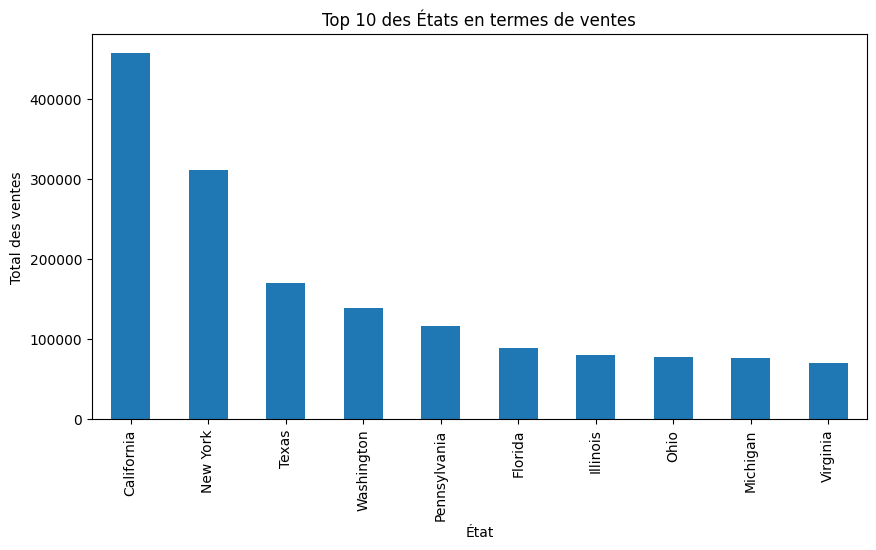

In [ ]:
import matplotlib.pyplot as plt
#agreger les ventes par etat, en remplaçant "Etat" par le nom correct de la colonne
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False)
#afficher les 10 premiers etats
state_sales.head(10).plot(kind="bar", figsize=(10,5), title="Top 10 des États en termes de ventes")
plt.xlabel("État")
plt.ylabel("Total des ventes")
plt.show()


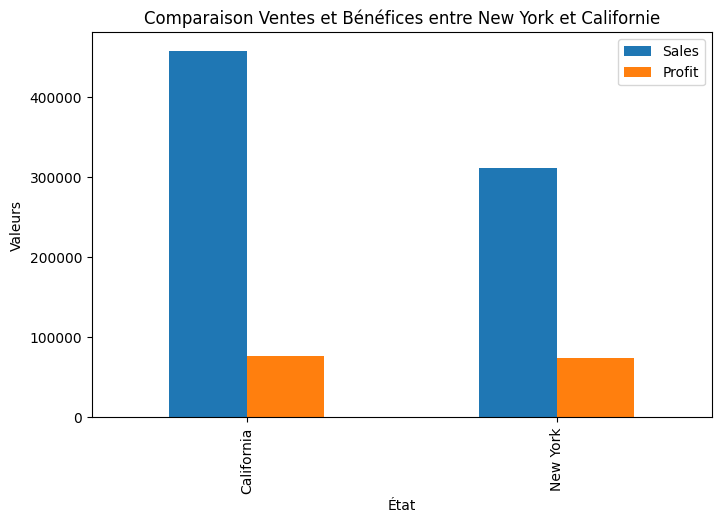

In [ ]:
#filtrer les données pour new york et californie
ny_ca = df[df["State"].isin(["New York", "California"])]
#comparer les ventes et bénéfices
ny_ca_grouped = ny_ca.groupby("State")[["Sales", "Profit"]].sum() # Remplacez "Ventes" par "Sales" et "Bénéfice" par "Profit"
ny_ca_grouped.plot(kind="bar", figsize=(8,5), title="Comparaison Ventes et Bénéfices entre New York et Californie")

plt.xlabel("État")
plt.ylabel("Valeurs")
plt.show()


In [ ]:
# Filtrer les clients de New York
ny_customers = df[df["State"] == "New York"] # Changed "Etat" to "State"

# Trouver le client avec le plus de ventes
top_ny_customer = ny_customers.groupby("Customer Name")["Sales"].sum().idxmax() # Assuming 'Nom du client' is 'Customer Name' and 'Ventes' is 'Sales'

print(f"Le client exceptionnel à New York est : {top_ny_customer}")

Le client exceptionnel à New York est : Tom Ashbrook


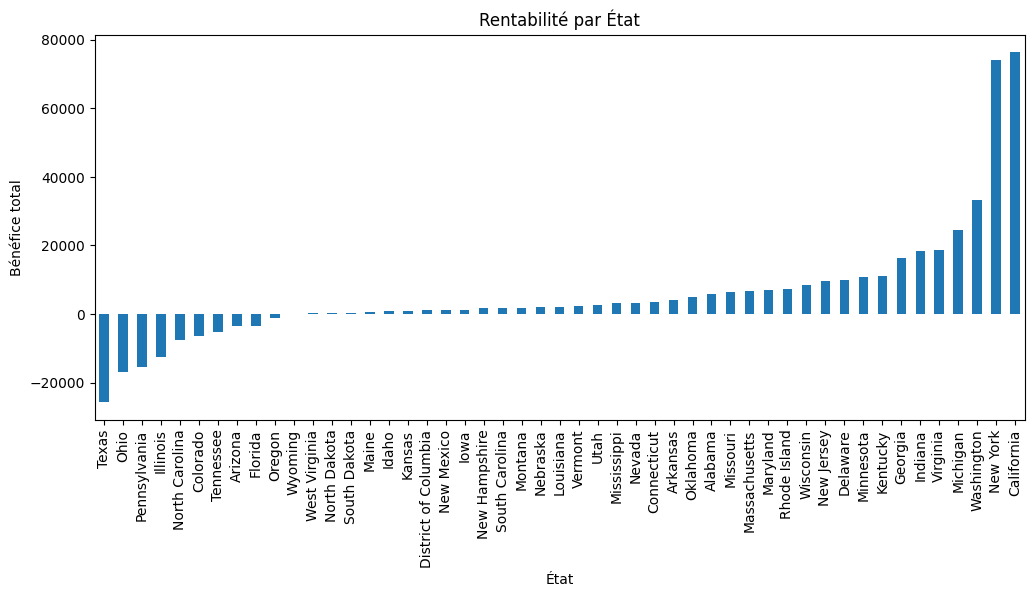

In [ ]:
# Agréger le bénéfice par État
state_profit = df.groupby("State")["Profit"].sum().sort_values() # Changed "Etat" to "State" and "Bénéfice" to "Profit"

# Afficher les États avec le plus et le moins de bénéfices
state_profit.plot(kind="bar", figsize=(12,5), title="Rentabilité par État")

plt.xlabel("État")
plt.ylabel("Bénéfice total")
plt.show()

In [ ]:
# Trier les clients par bénéfice décroissant
customer_profit = df.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False) # Changed "Nom du client" to "Customer Name" and "Bénéfice" to "Profit"

# Calcul du bénéfice cumulatif en %
cumulative_profit = customer_profit.cumsum() / customer_profit.sum()

# Trouver le point où 20% des clients contribuent à 80% des bénéfices
pareto_threshold = int(0.2 * len(customer_profit))
pareto_80 = cumulative_profit.iloc[pareto_threshold]

print(f"Les 20% des clients contribuent à {pareto_80:.2%} du bénéfice.")

Les 20% des clients contribuent à 81.66% du bénéfice.


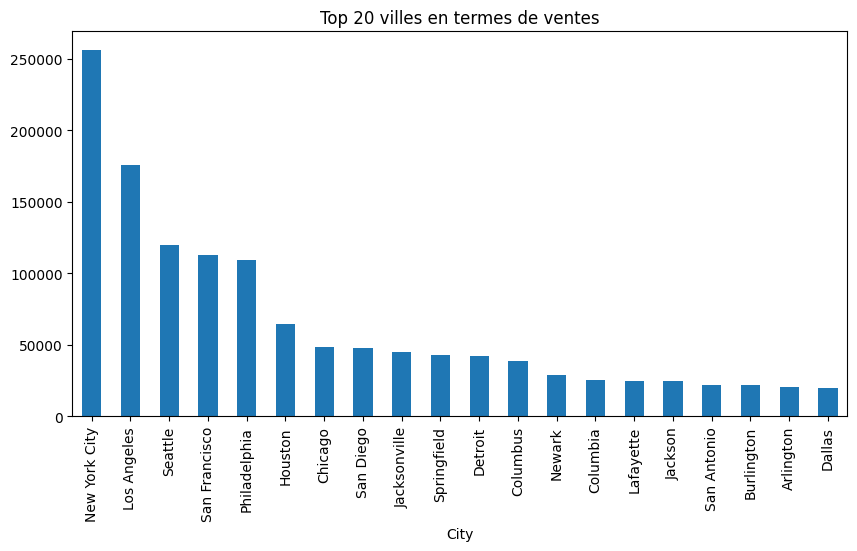

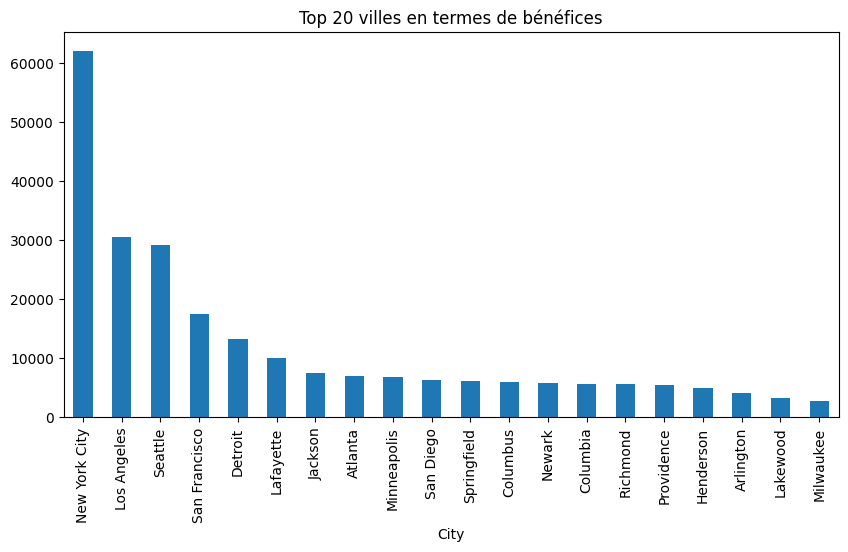

In [ ]:
# Agréger les ventes et bénéfices par ville
city_sales_profit = df.groupby("City")[["Sales", "Profit"]].sum() # Remplacez "Ville" par "City", "Ventes" par "Sales", et "Bénéfice" par "Profit"

# Trier et sélectionner les 20 premières villes
top_cities_sales = city_sales_profit["Sales"].sort_values(ascending=False).head(20)
top_cities_profit = city_sales_profit["Profit"].sort_values(ascending=False).head(20)

# Afficher les graphiques
top_cities_sales.plot(kind="bar", figsize=(10,5), title="Top 20 villes en termes de ventes")
plt.show()

top_cities_profit.plot(kind="bar", figsize=(10,5), title="Top 20 villes en termes de bénéfices")
plt.show()

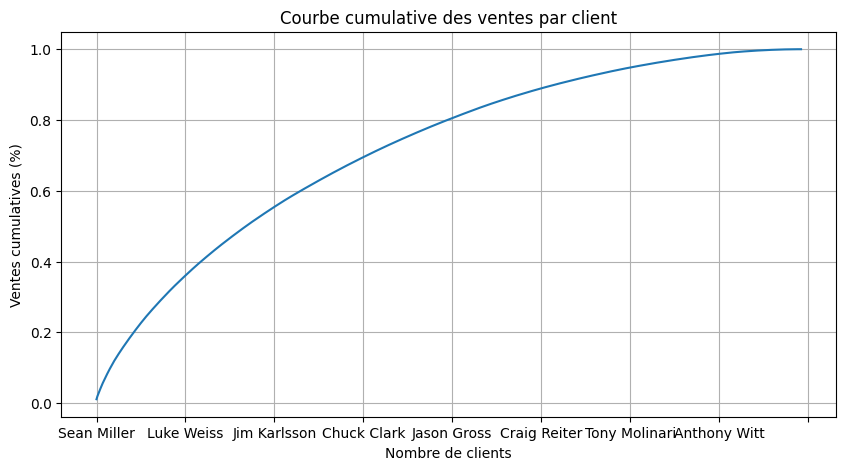

In [ ]:
# Trier les clients par ventes décroissantes
customer_sales = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False) # Remplacez "Nom du client" par "Customer Name" et "Ventes" par "Sales"

# Calcul des ventes cumulatives
cumulative_sales = customer_sales.cumsum() / customer_sales.sum()

# Tracer la courbe cumulative
cumulative_sales.plot(figsize=(10,5), title="Courbe cumulative des ventes par client")

plt.xlabel("Nombre de clients")
plt.ylabel("Ventes cumulatives (%)")
plt.grid()
plt.show()

conclusion : Concentrer le marketing sur les États et villes les plus rentables.
Mieux cibler les clients qui génèrent 80% du bénéfice.
Identifier les produits les plus rentables.